In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

In [6]:
# Load the final Random Forest model and its scaler

final_model = joblib.load(
    "../models/final_random_forest.pkl"
)

final_scaler = joblib.load(
    "../models/final_random_forest_scaler.pkl"
)

print(final_model)

print(final_scaler)

RandomForestClassifier(class_weight='balanced', max_features='log2',
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)
StandardScaler()


In [7]:
# Load the cleaned SWaT dataset

df = pd.read_csv(
    "../data/processed/SWaT_cleaned.csv"
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1441719, 46)
                 Timestamp    FIT101    LIT101  P101  P102    AIT202  \
0   28/12/2015 10:00:00 AM  2.427057  522.8467     2     1  8.396437   
1   28/12/2015 10:00:01 AM  2.446274  522.8860     2     1  8.396437   
2   28/12/2015 10:00:02 AM  2.489191  522.8467     2     1  8.394514   
3   28/12/2015 10:00:03 AM  2.534350  522.9645     2     1  8.394514   
4   28/12/2015 10:00:04 AM  2.569260  523.4748     2     1  8.394514   

     AIT203    FIT201  P203  P205  ...  P501  P502    PIT501    PIT502  \
0  328.6337  2.445391     2     2  ...     2     1  250.8652  1.649953   
1  328.6337  2.445391     2     2  ...     2     1  250.8652  1.649953   
2  328.6337  2.442316     2     2  ...     2     1  250.8812  1.649953   
3  328.6337  2.442316     2     2  ...     2     1  250.8812  1.649953   
4  328.6337  2.443085     2     2  ...     2     1  250.8812  1.649953   

     PIT503    FIT601  P601  P602  P603  Normal/Attack  
0  189.5988  0.000128     1     1   

In [8]:
# Prepare chronological data for final evaluation

df_time = df.copy()

# Convert Timestamp to datetime
df_time["Timestamp"] = pd.to_datetime(
    df_time["Timestamp"],
    format="mixed",
    dayfirst=True
)

# Sort data chronologically
df_time = df_time.sort_values(
    "Timestamp"
).reset_index(drop=True)

# Use the first 80% for training
# and the last 20% for final testing
split_index = int(len(df_time) * 0.8)

test_time = df_time.iloc[split_index:].copy()

print("Final test set shape:", test_time.shape)

print("\nTest label distribution:")
print(
    test_time["Normal/Attack"].value_counts()
)

Final test set shape: (288344, 46)

Test label distribution:
Normal/Attack
0    243102
1     45242
Name: count, dtype: int64


In [9]:
# Separate features from the target variable

X_final_test = test_time.drop(
    columns=["Timestamp", "Normal/Attack"]
)

y_final_test = test_time["Normal/Attack"]

print("X_final_test shape:", X_final_test.shape)
print("y_final_test shape:", y_final_test.shape)

X_final_test shape: (288344, 44)
y_final_test shape: (288344,)


In [10]:
# Transform the final test features using
# the scaler fitted on the time-based training data

X_final_test_scaled = final_scaler.transform(
    X_final_test
)

print(
    "X_final_test_scaled shape:",
    X_final_test_scaled.shape
)

X_final_test_scaled shape: (288344, 44)


In [12]:
# Generate predictions and probability scores
# using the final Random Forest model

y_final_pred = final_model.predict(
    X_final_test_scaled
)

y_final_proba = final_model.predict_proba(
    X_final_test_scaled
)[:, 1]



In [14]:
# Final classification report


print(
    classification_report(
        y_final_test,
        y_final_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.84      1.00      0.92    243102
      Attack       0.78      0.00      0.01     45242

    accuracy                           0.84    288344
   macro avg       0.81      0.50      0.46    288344
weighted avg       0.83      0.84      0.77    288344



In [15]:
# Calculate final ROC-AUC and PR-AUC

final_roc_auc = roc_auc_score(
    y_final_test,
    y_final_proba
)

final_pr_auc = average_precision_score(
    y_final_test,
    y_final_proba
)

print(f"Final ROC-AUC: {final_roc_auc:.4f}")
print(f"Final PR-AUC: {final_pr_auc:.4f}")

Final ROC-AUC: 0.9001
Final PR-AUC: 0.8407


In [16]:
# Confusion Matrix for the final model

cm = confusion_matrix(
    y_final_test,
    y_final_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[243055     47]
 [ 45080    162]]


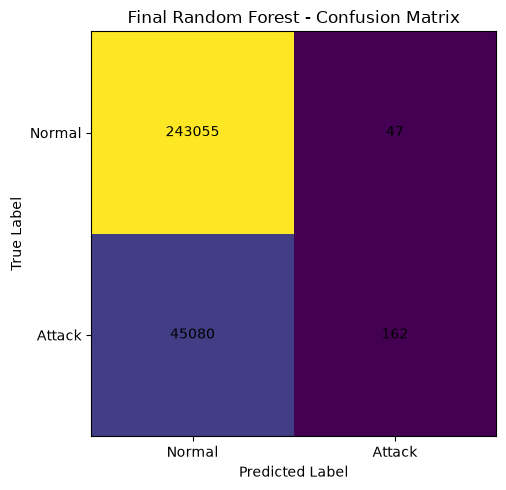

In [17]:
# Display the confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Final Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Normal", "Attack"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Attack"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Final Model - Threshold Tuning
# Evaluate different classification thresholds for the final
# time-based Random Forest model.

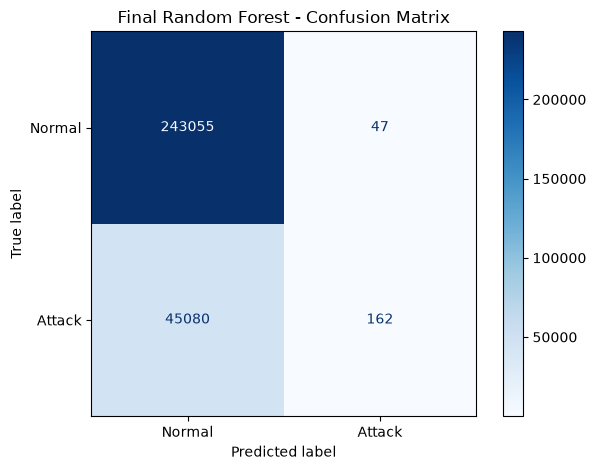

In [19]:
# Final Model - Confusion Matrix Visualization

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_final_test,
    y_final_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues"
)

plt.title("Final Random Forest - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Final Random Forest - Threshold Analysis

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_final_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_final_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_final_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_final_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("Final Random Forest - Threshold Analysis\n")
print(threshold_df.to_string(index=False))

Final Random Forest - Threshold Analysis

 Threshold  Precision   Recall       F1
      0.05   0.470210 0.814818 0.596307
      0.10   0.960868 0.746806 0.840420
      0.15   0.990902 0.724636 0.837106
      0.20   0.993446 0.720326 0.835123
      0.25   0.994091 0.710181 0.828488
      0.30   0.995293 0.640312 0.779281
      0.35   0.963175 0.033531 0.064806
      0.40   0.769231 0.003758 0.007479
      0.45   0.768182 0.003735 0.007435
      0.50   0.775120 0.003581 0.007129
      0.55   0.790244 0.003581 0.007129
      0.60   0.806283 0.003404 0.006779
      0.65   0.000000 0.000000 0.000000
      0.70   0.000000 0.000000 0.000000
      0.75   0.000000 0.000000 0.000000
      0.80   0.000000 0.000000 0.000000
      0.85   0.000000 0.000000 0.000000
      0.90   0.000000 0.000000 0.000000
      0.95   0.000000 0.000000 0.000000


In [21]:
# Select the threshold with the highest F1-score

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("\nBest Threshold:")
print(best_threshold_row)


Best Threshold:
Threshold    0.100000
Precision    0.960868
Recall       0.746806
F1           0.840420
Name: 1, dtype: float64


In [22]:
# Final classification threshold selected based on the highest F1-score
FINAL_THRESHOLD = 0.10

print("Final Threshold:", FINAL_THRESHOLD)

Final Threshold: 0.1


In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate final probability scores
y_final_proba = final_model.predict_proba(
    X_final_test_scaled
)[:, 1]

# Apply the selected final threshold
y_final_pred = (
    y_final_proba >= FINAL_THRESHOLD
).astype(int)

print("Final Classification Report:")
print(
    classification_report(
        y_final_test,
        y_final_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

print("Final ROC-AUC:",
      roc_auc_score(y_final_test, y_final_proba))

print("Final PR-AUC:",
      average_precision_score(y_final_test, y_final_proba))

print("Final Precision:",
      precision_score(y_final_test, y_final_pred))

print("Final Recall:",
      recall_score(y_final_test, y_final_pred))

print("Final F1:",
      f1_score(y_final_test, y_final_pred))

Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97    243102
      Attack       0.96      0.75      0.84     45242

    accuracy                           0.96    288344
   macro avg       0.96      0.87      0.91    288344
weighted avg       0.96      0.96      0.95    288344

Final ROC-AUC: 0.900110076931478
Final PR-AUC: 0.8406732401790992
Final Precision: 0.9608679577965475
Final Recall: 0.7468060651606914
Final F1: 0.8404203718674211


In [24]:
# Final confusion matrix using the selected threshold

cm_final = confusion_matrix(
    y_final_test,
    y_final_pred
)

print("Final Confusion Matrix:")
print(cm_final)

Final Confusion Matrix:
[[241726   1376]
 [ 11455  33787]]


In [25]:
# Final Model Summary

print("Final Model: Tuned Random Forest")
print("Classification Threshold: 0.10")

print("\nFinal Performance:")
print(f"ROC-AUC: {0.900110076931478:.4f}")
print(f"PR-AUC: {0.8406732401790992:.4f}")
print(f"Precision: {0.9608679577965475:.4f}")
print(f"Recall: {0.7468060651606914:.4f}")
print(f"F1-score: {0.8404203718674211:.4f}")

Final Model: Tuned Random Forest
Classification Threshold: 0.10

Final Performance:
ROC-AUC: 0.9001
PR-AUC: 0.8407
Precision: 0.9609
Recall: 0.7468
F1-score: 0.8404


In [28]:
# Save the selected classification threshold

final_threshold = 0.10

joblib.dump(
    final_threshold,
    "../models/final_random_forest_threshold.pkl"
)



['../models/final_random_forest_threshold.pkl']

In [30]:

# Feature Importance - Final Random Forest

feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X_final_test.columns
).sort_values(ascending=False)

print("Top 20 Features:")
print(feature_importance.head(20))

Top 20 Features:
AIT402     0.155007
AIT401     0.087832
PIT502     0.084522
PIT503     0.083351
AIT502     0.067080
PIT501     0.066322
FIT503     0.056231
FIT601     0.040485
AIT504     0.034614
AIT501     0.034023
FIT501     0.033001
AIT503     0.032550
AIT202     0.031379
FIT401     0.028210
FIT504     0.023490
AIT203     0.021411
DPIT301    0.021308
LIT301     0.015786
LIT101     0.014233
LIT401     0.012830
dtype: float64


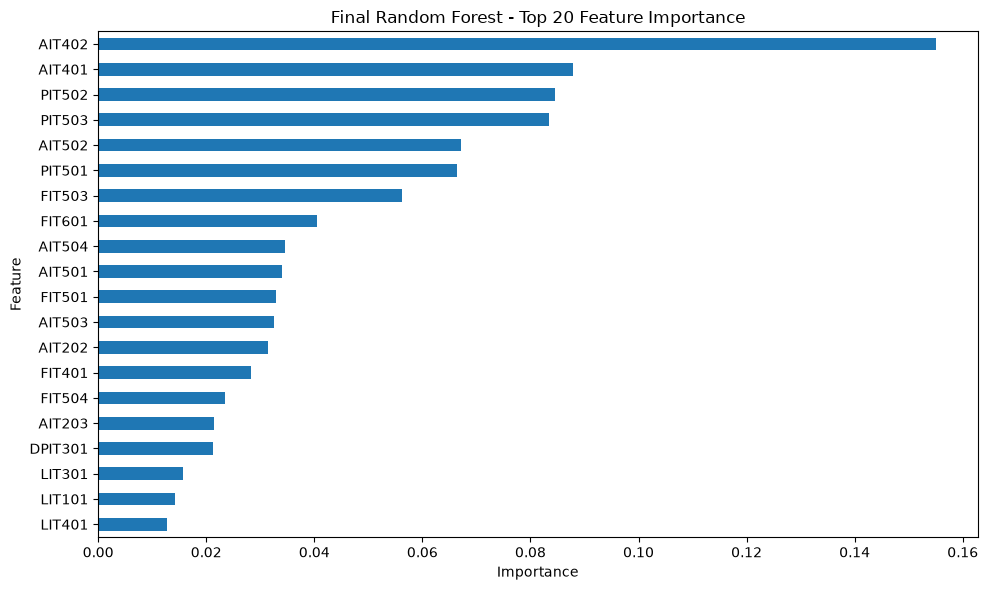

In [31]:

# Plot Top 20 Feature Importance

plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Final Random Forest - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:

# Save Feature Importance Results

feature_importance_df = (
    feature_importance
    .reset_index()
)

feature_importance_df.columns = [
    "Feature",
    "Importance"
]

feature_importance_df.to_csv(
    "../data/processed/final_random_forest_feature_importance.csv",
    index=False
)

In [36]:

# Permutation Importance - Final Random Forest

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_model,
    X_final_test_scaled,
    y_final_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_results = pd.Series(
    perm_importance.importances_mean,
    index=X_final_test.columns
).sort_values(ascending=False)

print(perm_results.head(20))

AIT402     0.014602
FIT401     0.014457
FIT201     0.010816
FIT301     0.008957
PIT503     0.008774
FIT504     0.006327
FIT501     0.005834
PIT502     0.005095
UV401      0.003949
LIT401     0.003893
AIT203     0.003685
P102       0.003370
FIT101     0.003361
AIT504     0.003079
PIT501     0.002504
LIT101     0.001734
DPIT301    0.001716
AIT502     0.001515
MV302      0.001314
FIT503     0.000597
dtype: float64


In [37]:

# Save Permutation Importance Results

perm_importance_df = (
    perm_results
    .reset_index()
)

perm_importance_df.columns = [
    "Feature",
    "Permutation_Importance"
]

perm_importance_df.to_csv(
    "../data/processed/final_random_forest_permutation_importance.csv",
    index=False
)



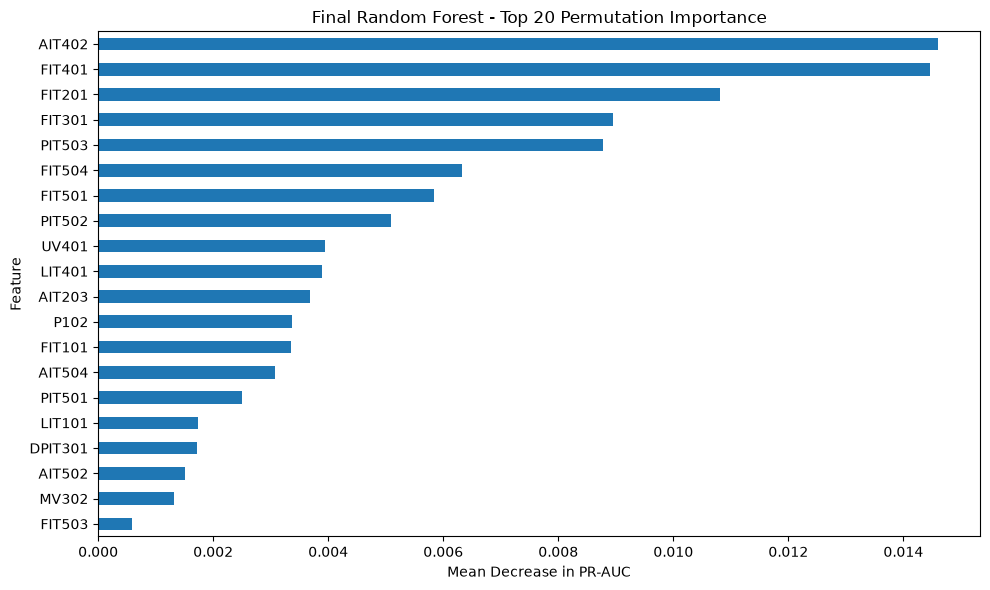

AIT402     0.014602
FIT401     0.014457
FIT201     0.010816
FIT301     0.008957
PIT503     0.008774
FIT504     0.006327
FIT501     0.005834
PIT502     0.005095
UV401      0.003949
LIT401     0.003893
AIT203     0.003685
P102       0.003370
FIT101     0.003361
AIT504     0.003079
PIT501     0.002504
LIT101     0.001734
DPIT301    0.001716
AIT502     0.001515
MV302      0.001314
FIT503     0.000597
dtype: float64


In [39]:

# Plot Top 20 Permutation Importance

plt.figure(figsize=(10, 6))

perm_results.head(20).sort_values().plot(
    kind="barh"
)

plt.title(
    "Final Random Forest - Top 20 Permutation Importance"
)

plt.xlabel("Mean Decrease in PR-AUC")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(perm_results.head(20))